In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

### Load data

In [ ]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir.csv'
data: pd.DataFrame = pd.read_csv(data_path)
#data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\victo\AppData\Local\Temp\ipykernel_33352\866007119.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

In [3]:
for matchid in tqdm(data["gameid"].unique()):
    game = data[data["gameid"] == matchid]
    teams = game["teamid"].unique()

    for teamid in teams:
        team = game[game["teamid"] == teamid]

        players = team[team["position"] != "team"]
        team_stats = team[team["position"] == "team"]

        # fill missing values in players with team stats if available
        for column in data.columns:
            if players[column].isnull().any():
                data.loc[players.index, column] = team_stats[column].item()

  0%|          | 0/10053 [00:00<?, ?it/s]

skip running above cell by loading the full imputated data

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)

C:\Users\victor\AppData\Local\Temp\ipykernel_13724\4154608675.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


In [ ]:
#data.to_csv("data_imputated.csv")

We then drop all rows that only contain teamwide statistics, as we are interested only in the player performances

In [3]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

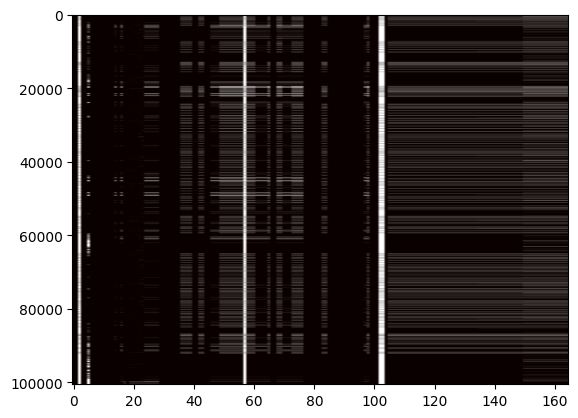

In [4]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [5]:
# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.20
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [6]:
100 * len(data) / data_len

71.58062269969163

% of the data rows, which represents 

In [7]:
len(data) / 10

7196.0

matches

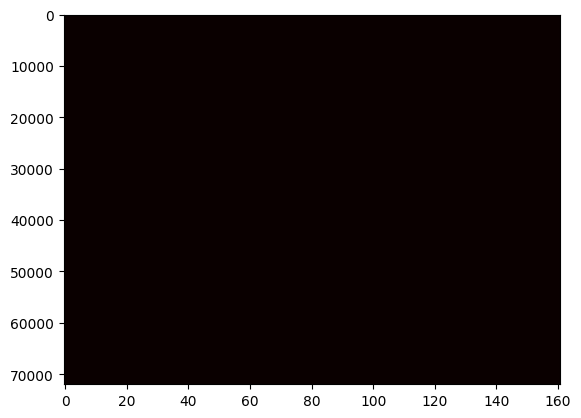

In [8]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [9]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "split", "side", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [10]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(71960, 1829)

This guves us a 1829-dimensional vector for each player-performance. Because of the curse of dimensionality this is too much to expect good results from, therefore we engineer a better vector by only keeping dimensions that are crucial for differentiating player performances. 

### Normalize data and calculate covariance and correlation matrix

In [11]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player match statistics that clusters each match statistic into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [12]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

In [15]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

Cluster 0:
position
mid    4850
top    4556
bot    3270
jng    3142
sup    1032
Name: count, dtype: int64


Cluster 1:
position
top    4043
bot    3556
mid    3451
jng    2664
sup     675
Name: count, dtype: int64


Cluster 2:
position
bot    5541
mid    3683
top    2331
jng    1236
sup     330
Name: count, dtype: int64


Cluster 3:
position
sup    8678
jng    3666
top     995
bot     718
mid     681
Name: count, dtype: int64


Cluster 4:
position
jng    3684
sup    3677
top    2467
mid    1727
bot    1307
Name: count, dtype: int64




We can see that we have one cluster where support is separated from the rest, but the other clusters are very mixed and don't really succeed in singling out specific roles. One reason this could be happening is due to the curse of dimensionality, we have 1800 dimensions and most of them are not important for clustering the points but having them increases the difficulty of the problem due to the curse of dimensionality. Our next approach is therefore to alleviate this by reducing the amount of dimensions. 

# Reducing the amount of dimensions

We pick out columns we have manually determined to likely play a big impact in differentiating player performances. Furthermore, we reduce the picked champion column from a one-hot encoding that takes 172 dimensions to a champion tag column that takes around 10 dimensions but is not a one-hot encoding, to do this we reduce the official league of legends champion class tags, for example, the champion Alistar is tagged as "Support" and "Tank", meaning the support and tank columns will have value 1, and the other columns will have value 0.

For this analysis we also take only the player performances from won games, as otherwise the main differentaiting factor between player performances may be whether they won or lost the game.

In [11]:
data_pure = data[data["result"] == 1]

In [60]:
data_pure = data

In [17]:
most_relevant_columns = ['champion', 'kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damageshare', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
for x in most_relevant_columns:
    if x not in data.columns:
        print(x)

In [61]:
data_pure = data_pure[most_relevant_columns + ["position"]]

In [62]:
from utility import champion_class_transform

data_pure = champion_class_transform(data_pure)

d:\Projects\uni\data_mining\Datamining_project\utility.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[tag] = dataframe["champion"].apply(lambda k: _is_class(tag, champion_json["data"][_clean(k)]["tags"]))
d:\Projects\uni\data_mining\Datamining_project\utility.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[tag] = dataframe["champion"].apply(lambda k: _is_class(tag, champion_json["data"][_clean(k)]["tags"]))
d:\Projects\uni\data_mining\Datamining_project\utility.py:55: SettingW

In [63]:
data_pure

,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,...,xpat25,csat25,goldat25,position,Mage,Support,Tank,Marksman,Assassin,Fighter
0,1,2,1,20156,759.6482,0.401970,681.2186,629.7362,7451.0,9,...,12552.0,217.0,9244.0,top,0,0,1,0,0,1
1,0,3,1,4963,187.0477,0.098977,906.9724,954.6106,0.0,7,...,8877.0,139.0,7040.0,jng,0,1,1,0,0,0
2,1,2,0,13952,525.8291,0.278244,366.8593,241.0553,0.0,12,...,10669.0,200.0,8488.0,mid,1,1,0,0,0,0
3,1,3,1,6898,259.9749,0.137567,479.2085,282.9271,333.0,6,...,11763.0,251.0,9097.0,bot,0,0,0,1,0,0
4,0,3,2,4174,157.3116,0.083242,474.5352,534.1583,0.0,40,...,6259.0,38.0,5357.0,sup,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118925,7,4,3,23862,794.5172,0.208589,1115.0610,953.0411,15070.0,11,...,13582.0,163.0,9586.0,top,0,0,0,0,0,1
118926,4,2,13,24935,830.2442,0.217969,2077.7913,1721.7869,2169.0,8,...,13438.0,203.0,8909.0,jng,0,0,1,0,0,1
118927,11,1,8,33608,1119.0233,0.293784,630.5327,311.5871,10599.0,13,...,14576.0,213.0,11651.0,mid,1,0,0,0,1,0
118928,4,1,12,25955,864.2064,0.226885,641.8535,325.5716,3175.0,11,...,12314.0,259.0,11098.0,bot,0,0,0,1,0,0


In [64]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(71960, 37)

### Normalize data and calculate covariance and correlation matrix

In [65]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

###  Clustering of known quantity

Can we make a clustering of player match statistics that clusters each match statistic into one of the 5 league of legends roles (Top / Jungle / Mid / Bottom / Support)?

We use k-means clustering with $k=5$. 

We need to remove the one-hot encoded player role ("position" column) from the data, as this is what we are hoping to determine with our clustering.

In [55]:
data_pure = data

In [66]:
position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

In [67]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

Cluster 0:
position
jng    5454
top    3814
sup    3802
mid    3136
bot    2072
Name: count, dtype: int64


Cluster 1:
position
bot    5439
mid    3514
top    2245
jng     890
sup     212
Name: count, dtype: int64


Cluster 2:
position
mid    5157
top    4141
bot    3647
jng    3483
sup    1232
Name: count, dtype: int64


Cluster 3:
position
top    3285
bot    2723
mid    2018
jng    1170
sup     320
Name: count, dtype: int64


Cluster 4:
position
sup    8826
jng    3395
top     907
mid     567
bot     511
Name: count, dtype: int64




Our clustering is better now, but still should be able to be much better. We can try to do a PCA dimensionality reduction to 2 dimensions and see if our data is clearly separable by position

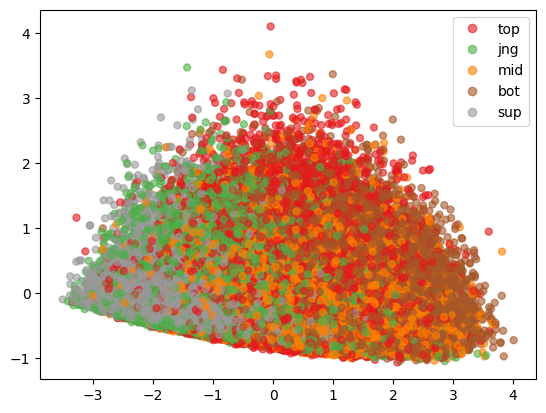

In [68]:
# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

In [ ]:
X_embedded = sklearn.manifold.TSNE(n_components=2, verbose=0).fit_transform(X_hat_no_position)
X_embedded.shape

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 71960 samples in 0.018s...
[t-SNE] Computed neighbors for 71960 samples in 14.044s...
[t-SNE] Computed conditional probabilities for sample 1000 / 71960
[t-SNE] Computed conditional probabilities for sample 2000 / 71960
[t-SNE] Computed conditional probabilities for sample 3000 / 71960
[t-SNE] Computed conditional probabilities for sample 4000 / 71960
[t-SNE] Computed conditional probabilities for sample 5000 / 71960
[t-SNE] Computed conditional probabilities for sample 6000 / 71960
[t-SNE] Computed conditional probabilities for sample 7000 / 71960
[t-SNE] Computed conditional probabilities for sample 8000 / 71960
[t-SNE] Computed conditional probabilities for sample 9000 / 71960
[t-SNE] Computed conditional probabilities for sample 10000 / 71960
[t-SNE] Computed conditional probabilities for sample 11000 / 71960
[t-SNE] Computed conditional probabilities for sample 12000 / 71960
[t-SNE] Computed conditional probabilities for sa

(71960, 2)

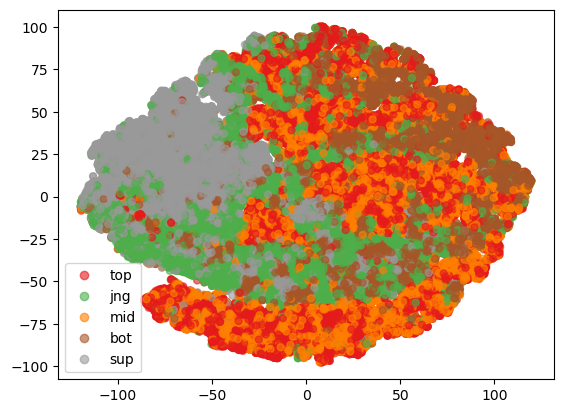

In [184]:
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()

Which turns out not to be the case, except for support

This may be due to the main variance in our data not being that of roles, but of other factors, such as whether or not the players won their games. If we do 2 clusters and look at the mean winrate in each cluster, we see that this is indeed the case: 

In [77]:
clustering = sklearn.cluster.KMeans(n_clusters=2).fit(X_hat_no_position)
print(np.mean(data.loc[clustering.labels_ == 0]["result"]))
print(np.mean(data.loc[clustering.labels_ == 1]["result"]))

0.5822452186162431
0.4133709981167608


Therefore, let's try filtering to only include won games. First we do a PCA plot: 

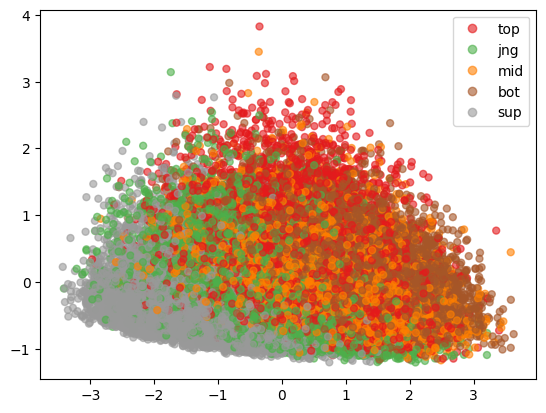

In [157]:
data_pure = data[data["result"] == 1]
data_pure = data_pure[most_relevant_columns + ["position"]]
data_pure = champion_class_transform(data_pure)
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()


And we see that the roles are now slightly better distinguished, let's try clustering now, and let's also plot the average total gold for each cluster. 

In [158]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print(data.loc[data["result"] == 0].iloc[np.where(clustering.labels_ == i)[0]]["totalgold"].mean())
    print("\n")

Cluster 0:
position
top    1568
jng    1323
mid    1067
bot     797
sup     405
Name: count, dtype: int64
10157.082558139535


Cluster 1:
position
bot    2983
mid    2238
top    1416
jng     737
sup     152
Name: count, dtype: int64
13876.277039596067


Cluster 2:
position
sup    5277
jng    1667
top     282
mid     149
bot      44
Name: count, dtype: int64
8216.934357730152


Cluster 3:
position
bot    2552
top    1741
mid    1410
jng     357
sup      52
Name: count, dtype: int64
11800.350294502618


Cluster 4:
position
jng    3112
mid    2332
top    2189
sup    1310
bot     820
Name: count, dtype: int64
10980.635357984225




As we can see support gets the least, while the "carry" (bot) gets the most, which is expected. Let's also print the average game length for each cluster: 

In [159]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data.loc[data["result"] == 1].iloc[np.where(clustering.labels_ == i)[0]]["gamelength"].mean())
    print("")

Cluster 0:
2166.3929950725797

Cluster 1:
1774.7058141780954

Cluster 2:
1893.7343724364232

Cluster 3:
1910.6568508807316

Cluster 4:
1940.879123130506



This is unusual, since 1 role goes into every game which has a fixed game length, role clusters should not be formed based on infered game length. The fact that this is happening means that game length causes a large amount of variance in our data, and we should thus normalize based on game length to alleviate this in order to form clusters that are based on roles rather than game length.

In order to normalize by game length we will take the average over all time-dependent columns for each time interval in our data and center our data around this mean. 

<Axes: >

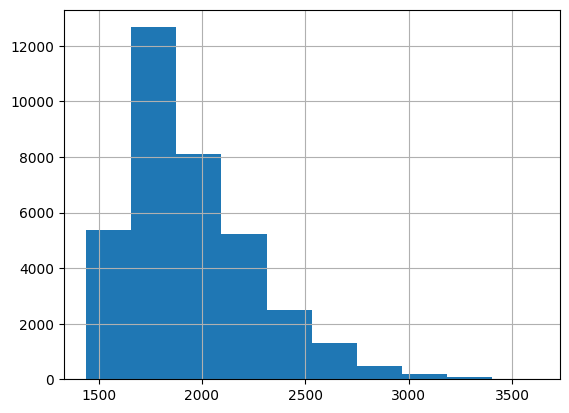

In [160]:
data.loc[data["result"] == 1]["gamelength"].hist()

In [161]:
min = np.min(data.loc[data["result"] == 1]["gamelength"])
max = np.max(data.loc[data["result"] == 1]["gamelength"])
k = 8
interval = (max - min) / k

for i in range(k):
    print(f'interval {(min + i * interval)/60:5.2f}m - {   (min + (i + 1) * interval)/60:5.2f}m: {len(data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)]):4d} games,  {data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)]["totalgold"].mean():5.2f} mean gold')

interval 24.00m - 28.54m: 8730 games,  11319.15 mean gold
interval 28.54m - 33.09m: 13475 games,  12400.35 mean gold
interval 33.09m - 37.63m: 8295 games,  13915.54 mean gold
interval 37.63m - 42.17m: 3385 games,  15395.45 mean gold
interval 42.17m - 46.72m: 1455 games,  16923.66 mean gold
interval 46.72m - 51.26m:  480 games,  18377.97 mean gold
interval 51.26m - 55.81m:  140 games,  19660.64 mean gold
interval 55.81m - 60.35m:   15 games,  22332.67 mean gold


In [163]:
time_dependent_columns = ["kills", "deaths", "assists","damagetochampions", "dpm", "damageshare", "damagetakenperminute", "damagemitigatedperminute", "damagetotowers", "wardsplaced", "visionscore", "totalgold", "minionkills", "monsterkills", "xpat10", "csat10", "goldat10", "xpat15", "csat15", "goldat15", "xpat20", "csat20", "goldat20", "xpat25", "csat25", "goldat25"]

for i in range(k):
    interval_indexes = data.loc[(data["result"] == 1) & (data["gamelength"] >= min + i * interval) & (data["gamelength"] < min + (i + 1) * interval)].index
    data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) - data_pure.loc[interval_indexes, time_dependent_columns].mean()
    data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) / data_pure.loc[interval_indexes, time_dependent_columns].std()

C:\Users\victor\AppData\Local\Temp\ipykernel_13724\2260304931.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.4580756 -3.4580756 -3.4580756 ...  7.5419244  6.5419244 -2.4580756]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_indexes, time_dependent_columns].astype(float) - data_pure.loc[interval_indexes, time_dependent_columns].mean()
C:\Users\victor\AppData\Local\Temp\ipykernel_13724\2260304931.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.50080183 -1.49919817 -0.49919817 ... -1.49919817  1.50080183
 -0.49919817]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_pure.loc[interval_indexes, time_dependent_columns] = data_pure.loc[interval_i

In [164]:
data_pure

,kills,deaths,assists,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,...,xpat25,csat25,goldat25,position,Mage,Support,Tank,Marksman,Assassin,Fighter
5,-0.450014,0.362976,-1.274275,-0.319843,-0.287490,0.759349,1.205498,0.843770,-0.198290,-0.387616,...,0.181422,0.320407,-0.420935,top,0,0,1,0,0,1
6,-1.067286,-1.086605,0.003244,-1.528904,-1.524612,-1.286810,-1.260906,-0.988822,-0.227358,-0.744477,...,-0.677238,-0.224701,-0.225292,jng,1,1,0,0,0,0
7,-1.067286,-0.361814,-0.422596,-0.149644,-0.113340,1.047391,-0.884300,-0.574062,-0.425448,-0.387616,...,0.404935,0.840160,0.100099,mid,1,1,0,0,0,0
8,1.093165,-1.086605,-1.487195,-0.279550,-0.246261,0.827544,-1.134478,-1.055650,1.016090,-0.601733,...,0.322224,1.042991,0.953166,bot,1,0,0,1,0,0
9,-1.375922,-1.086605,0.216164,-1.564749,-1.561289,-1.347474,-0.898695,-0.489768,-0.987691,1.824917,...,-1.957533,-1.961439,-1.953900,sup,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118925,0.881200,1.363098,-1.501362,0.628723,0.679193,0.098955,1.186177,0.593692,2.808258,-0.486800,...,0.805848,-0.147243,0.222242,top,0,0,0,0,0,1
118926,-0.069520,0.065116,0.659361,0.751928,0.805154,0.207023,4.072024,2.330212,-0.707512,-0.662149,...,0.751222,0.362572,-0.152100,jng,0,0,1,0,0,1
118927,2.148825,-0.583875,-0.421000,1.747782,1.823285,1.080497,-0.266228,-0.855289,1.589824,-0.369901,...,1.182915,0.490026,1.364069,mid,1,0,0,0,1,0
118928,-0.069520,-0.583875,0.443289,0.869047,0.924892,0.309746,-0.232293,-0.823699,-0.433358,-0.486800,...,0.324840,1.076312,1.058291,bot,0,0,0,1,0,0


In [115]:
X_hat_no_position

array([[-0.60988477, -0.61013234, -0.60963719, ..., -0.61062749,
        -0.61062749, -0.61037992],
       [-0.60530349, -0.60560457, -0.60259383, ..., -0.60560457,
        -0.60560457, -0.60560457],
       [-0.59175905, -0.59175905, -0.59015255, ..., -0.59198855,
        -0.59198855, -0.59198855],
       ...,
       [-0.52228077, -0.52375105, -0.52272185, ..., -0.52389808,
        -0.52375105, -0.52389808],
       [-0.52022147, -0.52077149, -0.51875478, ..., -0.52077149,
        -0.52095482, -0.52095482],
       [-0.58837501, -0.58756465, -0.58108181, ..., -0.58837501,
        -0.58837501, -0.58837501]], shape=(35980, 32))

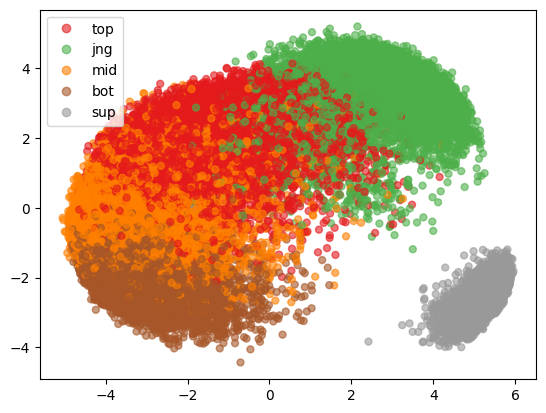

In [165]:
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

position_indexes = np.where(("position_top" == data_numeric.columns) | ("position_jng" == data_numeric.columns) | ("position_mid" == data_numeric.columns) | ("position_bot" == data_numeric.columns) | ("position_sup" == data_numeric.columns))
X_hat = X_normalized
X_hat_no_position = np.delete(X_hat, position_indexes, axis=1)
X_cor_no_position = np.cov(X_hat_no_position, rowvar=False)

# plot pca with position as color
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat_no_position)
X_pca = pca.transform(X_hat_no_position)
z = {"top": 0, "jng": 1, "mid": 2, "bot": 3, "sup": 4}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_pure["position"].apply(lambda x: z[x]), cmap="Set1", s=25, alpha=0.6)
handles, labels = scatter.legend_elements()
labels = ["top", "jng", "mid", "bot", "sup"]
plt.legend(handles, labels)
plt.show()


We can now see in the PCA plot that we get a much better distinction of roles, indicating that roles may be some of the largest determiners of variance in our data. When we plot the average game length per cluster we also see now that they do not depend on game length: 

In [167]:
clustering = sklearn.cluster.KMeans(n_clusters=5).fit(X_hat_no_position)
for i in range(5):
    print(f"Cluster {i}:")
    print(data.loc[data["result"] == 1].iloc[np.where(clustering.labels_ == i)[0]]["gamelength"].mean())
    print("")

Cluster 0:
1951.603320886629

Cluster 1:
1949.620665742025

Cluster 2:
1946.931226973317

Cluster 3:
1934.5806801736614

Cluster 4:
1960.193859255939



Let's print the role distribution in our clusters:

In [168]:
for i in range(5):
    print(f"Cluster {i}:")
    print(data_pure["position"].iloc[np.where(clustering.labels_ == i)[0]].value_counts())
    print("\n")

Cluster 0:
position
bot    7167
mid    4631
top     780
jng       8
sup       1
Name: count, dtype: int64


Cluster 1:
position
sup    7195
top       8
jng       3
bot       2
mid       2
Name: count, dtype: int64


Cluster 2:
position
top    6372
mid    2558
bot      27
Name: count, dtype: int64


Cluster 3:
position
jng    2763
top       1
Name: count, dtype: int64


Cluster 4:
position
jng    4422
top      35
mid       5
Name: count, dtype: int64




And we see that we now get one cluster that accurately determines "support", two clusters that combined accurately determines "jungle", one that shares top/mid and one that primarily predicts "bot". 

### Clustering of unknown quantity

We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [185]:
X_hat = X_normalized


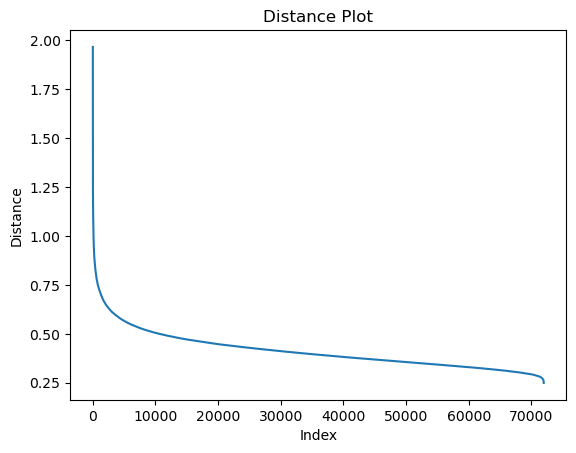

In [186]:
neighbors = 2*X_hat.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
distances, indices = nbrs.kneighbors(X_hat)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=5, min_samples = neighbors).fit(X_hat)

In [ ]:
labels = np.unique(density_cluster.labels_)
labels

We see using this method we only get one cluster, which is not entirely surprising considering the very high dimensionality of the data which is causing min pts to be very large based on the heuristic. To try to alleviate this we cna use PCA to reduce dimensionality to hopefully improve the results.

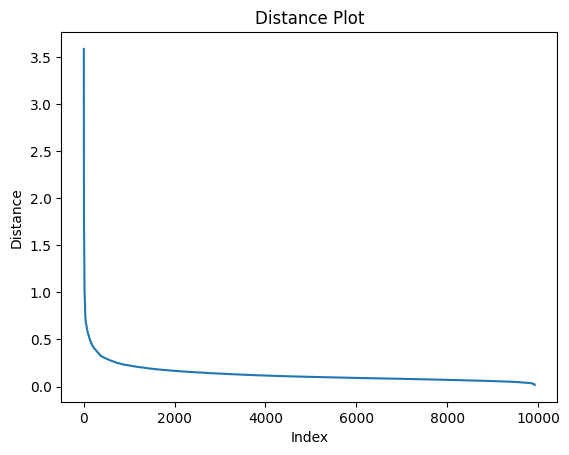

In [ ]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 2*X_pca.shape[1]
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.3, min_samples = neighbors).fit(X_pca)
labels = np.unique(density_cluster.labels_)
labels

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
      dtype=int64)

Now we are seeing a few too many clusters due to the rule of thumb for min pts not really working well for this type of data, as we ideally want to group games fall into more broad clusters. So we will manually set min pts to 20.

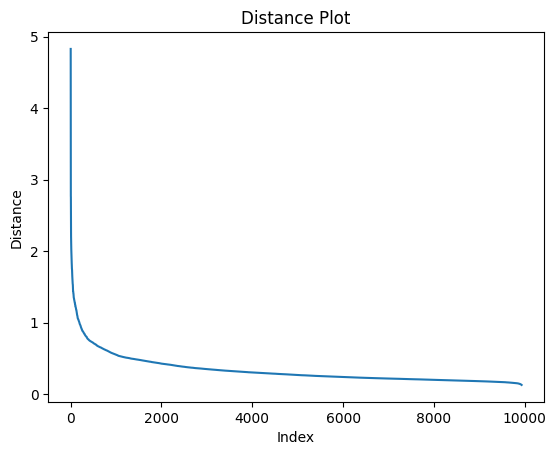

In [ ]:
neighbors = 20
nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
distance_desc = sorted(distances[:,neighbors-1], reverse=True)
plt.plot(
    range(1, len(distance_desc) + 1),
    distance_desc
)

plt.xlabel("Index")
plt.ylabel("Distance")
plt.title("Distance Plot")

plt.show()

In [ ]:
density_cluster = sklearn.cluster.DBSCAN(eps=0.6, min_samples = neighbors).fit(X_pca)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0,  1,  2], dtype=int64)

In [81]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1,  0,  1,  2], dtype=int64),
 array([ 426, 9473,   13,   18], dtype=int64))

Now we are getting a more reasonable 3 clusters, though one cluster is highly represented 

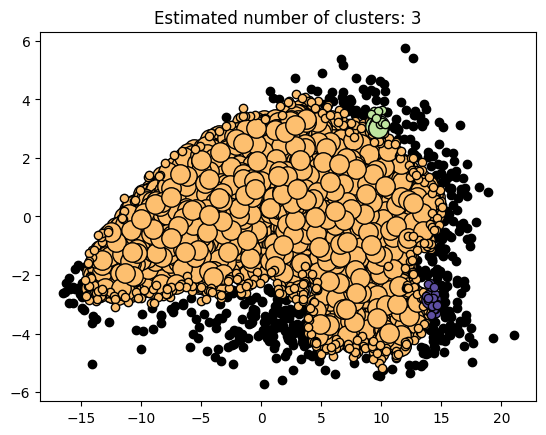

In [78]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

This can be read as that a vast perfomances being similar, though we should still try to investigate a bit further

We can try to use OPTICS instead since it is better suited for such high dimensional data